# Coreset versus Random Sampling

## Objective
Compare representative feature selection with random sampling for
bottle anomaly detection at equal memory budgets.

## Fixed settings
- Reuse the baseline's training, validation, and test embeddings.
- Memory sizes: 131, 658, and 1,317 vectors.
- Seeds: 42, 43, and 44.
- Calibrate each threshold using normal validation images only.
- Report all configurations on the existing bottle benchmark.

## Selection method
Use greedy farthest-first selection after projecting training features
from 1,024 to 128 dimensions.

Select using projected features, but score images using the original
1,024-dimensional vectors.

This is a documented approximation, not an exact reproduction of
the official PatchCore sampler.

In [1]:
from google.colab import drive
from pathlib import Path
import torch
import numpy as np
import pandas as pd

drive.mount("/content/drive")

# The leading space matches the Drive folder we used previously.
artifact_dir = Path(
    "/content/drive/MyDrive/ AI-Engineering-Journey/"
    "artifacts/patchcore-bottle"
)

required_files = [
    "full_memory_bank.pt",
    "metadata.json",
    "validation_embeddings_v1.pt",
    "test_embeddings_v1.pt",
    "random_memory_comparison.csv",
]

missing = [
    name for name in required_files
    if not (artifact_dir / name).is_file()
]

if missing:
    raise FileNotFoundError(
        "Missing saved artifacts:\n" + "\n".join(missing)
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("All required artifacts found.")

Mounted at /content/drive
Device: cuda
All required artifacts found.


In [2]:
# to restore the expriment data
import json

memory_bank = torch.load(
    artifact_dir / "full_memory_bank.pt",
    map_location="cpu",
    weights_only=True,
)

validation_cache = torch.load(
    artifact_dir / "validation_embeddings_v1.pt",
    map_location="cpu",
    weights_only=True,
)

test_cache = torch.load(
    artifact_dir / "test_embeddings_v1.pt",
    map_location="cpu",
    weights_only=True,
)

with open(artifact_dir / "metadata.json") as file:
    metadata = json.load(file)

random_results = pd.read_csv(
    artifact_dir / "random_memory_comparison.csv"
)

# Confirm that we restored the expected baseline artifacts.
assert memory_bank.shape == (131712, 1024)
assert validation_cache["embeddings"].shape == (41, 784, 1024)
assert test_cache["embeddings"].shape == (83, 784, 1024)

assert (
    validation_cache["paths"] == metadata["validation_images"]
), "Validation image order differs from the saved split."

assert set(metadata["training_images"]).isdisjoint(
    validation_cache["paths"]
), "Training and validation images overlap."

print("Training memory:", tuple(memory_bank.shape))
print("Validation cache:", tuple(validation_cache["embeddings"].shape))
print("Test cache:", tuple(test_cache["embeddings"].shape))
print("Random baseline runs:", len(random_results))

Training memory: (131712, 1024)
Validation cache: (41, 784, 1024)
Test cache: (83, 784, 1024)
Random baseline runs: 9


## Representative memory selection

We project training embeddings to 128 dimensions to reduce selection cost.

Greedy farthest-first selection:
1. Choose a starting training vector.
2. Track each vector's distance to its nearest selected vector.
3. Select the vector with the largest nearest distance.
4. Update those distances and repeat.

Only training features participate in selection.
The selected indices retrieve original 1,024-dimensional vectors for scoring.

This is an approximate coreset approach using Gaussian random projection,
not an exact reproduction of the official PatchCore sampler.

In [3]:
@torch.inference_mode()
def project_for_selection(memory_bank, seed, output_dim=128):
    generator = torch.Generator(device="cpu").manual_seed(seed)

    projection = torch.randn(
        memory_bank.shape[1],
        output_dim,
        generator=generator,
        dtype=torch.float32,
    ) / np.sqrt(output_dim)

    projection = projection.to(device)

    projected = torch.empty(
        len(memory_bank),
        output_dim,
        device=device,
        dtype=torch.float32,
    )

    for start in range(0, len(memory_bank), 4096):
        end = min(start + 4096, len(memory_bank))

        projected[start:end] = (
            memory_bank[start:end].to(
                device=device, dtype=torch.float32
            )
            @ projection
        )

    return projected


projected_memory = project_for_selection(memory_bank, seed=42)

assert projected_memory.shape == (131712, 128)
assert torch.isfinite(projected_memory).all()

print("Selection features:", tuple(projected_memory.shape))

Selection features: (131712, 128)


In [4]:
from tqdm.auto import tqdm


@torch.inference_mode()
def greedy_farthest_first(projected, count, seed):
    total = len(projected)

    if not 1 <= count <= total:
        raise ValueError("Selection count must be between 1 and bank size.")

    generator = torch.Generator(device="cpu").manual_seed(seed)

    current = int(torch.randint(
        total, (1,), generator=generator
    ).item())

    selected = torch.empty(
        count, dtype=torch.long, device=projected.device
    )

    # Distance to the nearest selected vector.
    nearest_distance = torch.full(
        (total,), float("inf"), device=projected.device
    )

    for step in tqdm(range(count), desc=f"Coreset seed {seed}"):
        selected[step] = current

        # Direct squared differences avoid cancellation from
        # subtracting large dot products.
        for start in range(0, total, 8192):
            end = min(start + 8192, total)

            squared_distance = (
                projected[start:end] - projected[current]
            ).square().sum(dim=1)

            nearest_distance[start:end] = torch.minimum(
                nearest_distance[start:end],
                squared_distance,
            )

        # Prevent already-selected indices from being chosen again.
        nearest_distance[selected[:step + 1]] = -1.0

        if step + 1 < count:
            current = int(nearest_distance.argmax().item())

    return selected.cpu()


coreset_indices = greedy_farthest_first(
    projected_memory,
    count=1317,
    seed=42,
)

assert len(coreset_indices.unique()) == 1317

coreset_bank = memory_bank[coreset_indices].contiguous()

torch.save(
    {
        "indices": coreset_indices,
        "seed": 42,
        "projection_dim": 128,
        "projection": "Gaussian, scaled by 1/sqrt(output_dim)",
        "selection": "greedy farthest-first with random starting vector",
        "torch_version": str(torch.__version__),
    },
    artifact_dir / "coreset_indices_seed42_v1.pt",
)

print("Selected indices:", tuple(coreset_indices.shape))
print("Scoring bank:", tuple(coreset_bank.shape))
print("Saved coreset indices to Drive.")

Coreset seed 42:   0%|          | 0/1317 [00:00<?, ?it/s]

Selected indices: (1317,)
Scoring bank: (1317, 1024)
Saved coreset indices to Drive.


Important interpretation: selection favors coverage, not necessarily the most common patterns. It may also select unusual normal examples or annotation problems. Better test performance is a hypothesis we’ll evaluate not a guaranteed outcome.

## Evaluate coreset memory budgets — seed 42

Evaluate nested banks containing 131, 658, and 1,317 vectors.

Each bank receives its own threshold, calibrated from the same
41 normal validation images. Test images are used only for evaluation.

Compare these results against random sampling with seed 42.

In [5]:
from pathlib import PurePosixPath
from sklearn.metrics import confusion_matrix, roc_auc_score


@torch.inference_mode()
def score_cached_images(cached_embeddings, bank):
    reference = bank.to(device)
    image_scores = []

    for image_embeddings in cached_embeddings:
        embeddings = image_embeddings.to(device)
        patch_scores = []

        for chunk in embeddings.split(128):
            distances = torch.cdist(chunk, reference, p=2)
            patch_scores.append(
                distances.min(dim=1).values.square()
            )

        image_scores.append(
            torch.cat(patch_scores).max().item()
        )

    return np.array(image_scores)


validation_embeddings = validation_cache["embeddings"]
test_embeddings = test_cache["embeddings"]

test_labels = np.array([
    int(PurePosixPath(path).parent.name != "good")
    for path in test_cache["paths"]
])

# Load the saved selection explicitly.
selection = torch.load(
    artifact_dir / "coreset_indices_seed42_v1.pt",
    map_location="cpu",
    weights_only=True,
)
indices = selection["indices"]

coreset_rows = []
score_rows = []

for ratio in tqdm([0.001, 0.005, 0.01], desc="Evaluating coreset"):
    count = int(len(memory_bank) * ratio)
    bank = memory_bank[indices[:count]].contiguous()

    validation_scores = score_cached_images(
        validation_embeddings, bank
    )
    threshold = float(
        np.quantile(validation_scores, 0.95, method="higher")
    )

    test_scores = score_cached_images(test_embeddings, bank)
    predictions = (test_scores > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        test_labels, predictions, labels=[0, 1]
    ).ravel()

    coreset_rows.append({
        "method": "coreset",
        "seed": 42,
        "ratio": ratio,
        "vectors": count,
        "memory_mib": bank.numel() * bank.element_size() / 1024**2,
        "threshold": threshold,
        "validation_false_alarms": int(
            (validation_scores > threshold).sum()
        ),
        "test_false_alarms": int(fp),
        "test_missed_defects": int(fn),
        "test_defect_recall": tp / (tp + fn),
        "test_auroc": roc_auc_score(test_labels, test_scores),
    })

    for split, cache, scores in [
        ("validation", validation_cache, validation_scores),
        ("test", test_cache, test_scores),
    ]:
        for path, score in zip(cache["paths"], scores):
            score_rows.append({
                "method": "coreset",
                "seed": 42,
                "ratio": ratio,
                "split": split,
                "image": path,
                "score": float(score),
                "threshold": threshold,
            })

coreset_results = pd.DataFrame(coreset_rows)

coreset_results.to_csv(
    artifact_dir / "coreset_comparison_seed42.csv",
    index=False,
)
pd.DataFrame(score_rows).to_csv(
    artifact_dir / "coreset_scores_seed42.csv",
    index=False,
)

comparison = pd.concat([
    random_results[
        (random_results["method"] == "random")
        & (random_results["seed"] == 42)
    ],
    coreset_results,
], ignore_index=True).sort_values(["ratio", "method"])

display(comparison[[
    "method", "ratio", "vectors", "threshold",
    "test_false_alarms", "test_missed_defects",
    "test_defect_recall", "test_auroc",
]].round(4))

print("Coreset results and per-image scores saved.")

Evaluating coreset:   0%|          | 0/3 [00:00<?, ?it/s]

,method,ratio,vectors,threshold,test_false_alarms,test_missed_defects,test_defect_recall,test_auroc
3,coreset,0.001,131,4.4382,0,0,1.0000,1.0000
0,random,0.001,131,6.9298,1,10,0.8413,0.9405
4,coreset,0.005,658,3.0050,1,0,1.0000,1.0000
1,random,0.005,658,3.6262,1,0,1.0000,0.9984
5,coreset,0.010,1317,2.6256,2,0,1.0000,1.0000
2,random,0.010,1317,3.3225,0,0,1.0000,1.0000


Coreset results and per-image scores saved.


What this means
- At 131 vectors, selecting representative features worked substantially better than choosing them randomly: no missed defects and no false alarms, using the same feature storage.
- At 658 vectors, both methods made the same classification errors, although coreset achieved better ranking.
- At 1,317 vectors, coreset still ranked perfectly but produced two false alarms at its validation-derived threshold. It did not outperform random sampling on every measure.

```
```



## Repeat coreset experiments across seeds

Repeat selection and evaluation for seeds 43 and 44.

Keep the projection dimension, memory budgets, scoring method, and
validation threshold rule unchanged. Report every configuration.

Seed variability includes changes in both the random projection
and the initial selected vector.

In [6]:
required = [
    "project_for_selection",
    "greedy_farthest_first",
    "score_cached_images",
    "memory_bank",
    "validation_cache",
    "test_cache",
    "test_labels",
    "artifact_dir",
    "random_results",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Run the earlier setup cells first: " + ", ".join(missing))

for seed in [43, 44]:
    print(f"\n--- Seed {seed} ---")

    selection_path = artifact_dir / f"coreset_indices_seed{seed}_v1.pt"

    # Reuse a completed selection if this cell is rerun.
    if selection_path.exists():
        saved = torch.load(
            selection_path,
            map_location="cpu",
            weights_only=True,
        )
        indices = saved["indices"]
        print("Loaded saved selection.")
    else:
        projected = project_for_selection(memory_bank, seed=seed)

        indices = greedy_farthest_first(
            projected,
            count=1317,
            seed=seed,
        )

        torch.save(
            {
                "indices": indices,
                "seed": seed,
                "projection_dim": 128,
                "projection": "Gaussian, scaled by 1/sqrt(output_dim)",
                "selection": "greedy farthest-first with random starting vector",
                "torch_version": str(torch.__version__),
            },
            selection_path,
        )

        del projected

    assert len(indices) == len(indices.unique()) == 1317

    rows = []
    per_image_rows = []

    for ratio in tqdm([0.001, 0.005, 0.01], desc=f"Evaluate seed {seed}"):
        count = int(len(memory_bank) * ratio)
        bank = memory_bank[indices[:count]].contiguous()

        val_scores = score_cached_images(
            validation_cache["embeddings"], bank
        )
        threshold = float(
            np.quantile(val_scores, 0.95, method="higher")
        )

        test_scores = score_cached_images(
            test_cache["embeddings"], bank
        )
        predictions = (test_scores > threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            test_labels, predictions, labels=[0, 1]
        ).ravel()

        rows.append({
            "method": "coreset",
            "seed": seed,
            "ratio": ratio,
            "vectors": count,
            "memory_mib": bank.numel() * bank.element_size() / 1024**2,
            "threshold": threshold,
            "validation_false_alarms": int((val_scores > threshold).sum()),
            "test_false_alarms": int(fp),
            "test_missed_defects": int(fn),
            "test_defect_recall": tp / (tp + fn),
            "test_auroc": roc_auc_score(test_labels, test_scores),
        })

        for split, cache, scores in [
            ("validation", validation_cache, val_scores),
            ("test", test_cache, test_scores),
        ]:
            for path, score in zip(cache["paths"], scores):
                per_image_rows.append({
                    "method": "coreset",
                    "seed": seed,
                    "ratio": ratio,
                    "split": split,
                    "image": path,
                    "score": float(score),
                    "threshold": threshold,
                })

        # Save progress after each memory budget.
        pd.DataFrame(rows).to_csv(
            artifact_dir / f"coreset_comparison_seed{seed}.csv",
            index=False,
        )
        pd.DataFrame(per_image_rows).to_csv(
            artifact_dir / f"coreset_scores_seed{seed}.csv",
            index=False,
        )

    print(f"Seed {seed} completed and saved.")


--- Seed 43 ---


Coreset seed 43:   0%|          | 0/1317 [00:00<?, ?it/s]

Evaluate seed 43:   0%|          | 0/3 [00:00<?, ?it/s]

Seed 43 completed and saved.

--- Seed 44 ---


Coreset seed 44:   0%|          | 0/1317 [00:00<?, ?it/s]

Evaluate seed 44:   0%|          | 0/3 [00:00<?, ?it/s]

Seed 44 completed and saved.


In [7]:
# combine all three seeds into one comparison table
coreset_results = pd.concat([
    pd.read_csv(artifact_dir / f"coreset_comparison_seed{seed}.csv")
    for seed in [42, 43, 44]
], ignore_index=True)

assert len(coreset_results) == 9
assert not coreset_results.duplicated(["seed", "ratio"]).any()

all_results = pd.concat([
    random_results[random_results["method"] == "random"],
    coreset_results,
], ignore_index=True).sort_values(["ratio", "seed", "method"])

assert len(all_results) == 18

all_results.to_csv(
    artifact_dir / "random_vs_coreset_comparison.csv",
    index=False,
)

display(all_results[[
    "method",
    "seed",
    "vectors",
    "test_false_alarms",
    "test_missed_defects",
    "test_defect_recall",
    "test_auroc",
]].round(4))

print("Saved the full 18-run comparison.")

,method,seed,vectors,test_false_alarms,test_missed_defects,test_defect_recall,test_auroc
9,coreset,42,131,0,0,1.0000,1.0000
0,random,42,131,1,10,0.8413,0.9405
12,coreset,43,131,2,1,0.9841,0.9952
3,random,43,131,0,8,0.8730,0.9381
15,coreset,44,131,1,0,1.0000,1.0000
6,random,44,131,1,4,0.9365,0.9817
10,coreset,42,658,1,0,1.0000,1.0000
1,random,42,658,1,0,1.0000,0.9984
13,coreset,43,658,2,0,1.0000,1.0000
4,random,43,658,1,1,0.9841,0.9984


Saved the full 18-run comparison.


On the MVTec AD bottle benchmark, approximate coreset selection improved defect detection over random sampling under a tight feature-memory budget. At larger budgets, the advantage narrowed, and coreset did not consistently reduce false alarms.

## Results: coreset versus random sampling

We compare both methods at equal feature-memory budgets:
131, 658, and 1,317 vectors.

Each configuration uses its own threshold calibrated from 41 normal
validation images. All runs use the same 83 test images:
20 normal and 63 defective.

The charts show individual seeds rather than only averages.

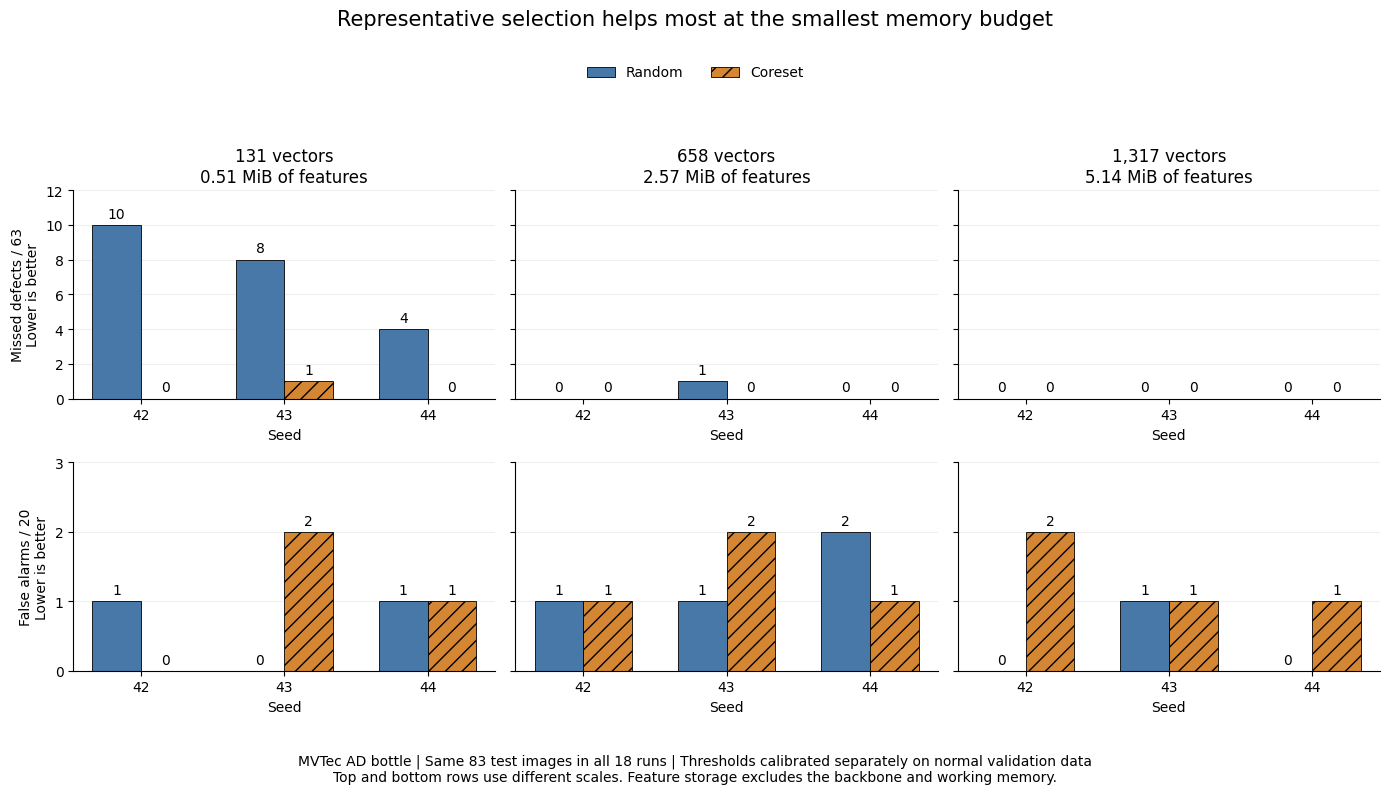

Saved: /content/drive/MyDrive/ AI-Engineering-Journey/artifacts/patchcore-bottle/figures/random_vs_coreset_errors.png


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

results_path = artifact_dir / "random_vs_coreset_comparison.csv"
comparison = pd.read_csv(results_path)

methods = ["random", "coreset"]
seeds = [42, 43, 44]
budgets = [131, 658, 1317]

expected = {
    (method, seed, budget)
    for method in methods
    for seed in seeds
    for budget in budgets
}

actual = set(
    comparison[["method", "seed", "vectors"]]
    .itertuples(index=False, name=None)
)

assert len(comparison) == 18
assert actual == expected, "Some experiment configurations are missing."
assert not comparison.duplicated(["method", "seed", "vectors"]).any()

styles = {
    "random": {
        "color": "#4878A8",
        "hatch": "",
        "label": "Random",
    },
    "coreset": {
        "color": "#D48632",
        "hatch": "//",
        "label": "Coreset",
    },
}

metrics = [
    ("test_missed_defects", "Missed defects / 63"),
    ("test_false_alarms", "False alarms / 20"),
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8),
    sharey="row",
)

x = np.arange(len(seeds))
width = 0.34

for column, budget in enumerate(budgets):
    subset = comparison[comparison["vectors"] == budget]
    memory_mib = subset["memory_mib"].iloc[0]

    for row, (metric, ylabel) in enumerate(metrics):
        ax = axes[row, column]

        for method_index, method in enumerate(methods):
            values = (
                subset[subset["method"] == method]
                .set_index("seed")
                .loc[seeds, metric]
            )

            positions = x + (method_index - 0.5) * width
            style = styles[method]

            bars = ax.bar(
                positions,
                values,
                width=width,
                color=style["color"],
                hatch=style["hatch"],
                edgecolor="black",
                linewidth=0.6,
                label=style["label"],
            )
            ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)

        ax.set_xticks(x, [str(seed) for seed in seeds])
        ax.set_xlabel("Seed")
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_axisbelow(True)
        ax.grid(axis="y", alpha=0.2)
        ax.spines[["top", "right"]].set_visible(False)

        if column == 0:
            ax.set_ylabel(ylabel + "\nLower is better")

        if row == 0:
            ax.set_title(
                f"{budget:,} vectors\n{memory_mib:.2f} MiB of features"
            )

# Identical scales across budgets for each metric.
for ax in axes[0]:
    ax.set_ylim(0, comparison["test_missed_defects"].max() + 2)

for ax in axes[1]:
    ax.set_ylim(0, comparison["test_false_alarms"].max() + 1)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Representative selection helps most at the smallest memory budget",
    fontsize=15,
    y=0.99,
)

fig.text(
    0.5, 0.025,
    "MVTec AD bottle | Same 83 test images in all 18 runs | "
    "Thresholds calibrated separately on normal validation data\n"
    "Top and bottom rows use different scales. "
    "Feature storage excludes the backbone and working memory.",
    ha="center",
    fontsize=10,
)

fig.tight_layout(rect=[0, 0.09, 1, 0.88])

figures_dir = artifact_dir / "figures"
figures_dir.mkdir(exist_ok=True)

figure_path = figures_dir / "random_vs_coreset_errors.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)